In [1]:
# ============================================================
# BANK BRANCH RISK & OPERATIONAL STABILITY ANALYSIS
# SQL + Python + Power BI
# ============================================================


# Bank Branch Risk–Return Portfolio Analysis

## Notebook Index

### 1. Data Preparation
- load the transaction-level banking dataset
- clean column names and date fields
- create SQLite table for analysis

### 2. Portfolio Structure Analysis
- branch-level loan exposure
- Herfindahl-Hirschman Index (HHI)
- client concentration Gini

### 3. Operational Stability Metrics
- credit utilization (CCU)
- anomaly analysis
- transaction volatility
- Revenue Stability Index (RSI)

### 4. Final Branch Feature Table
- merge concentration, stability, and loan mix features
- remove circular normalized RSI component columns

### 5. Interest Revenue and Loan Status
- estimate annualized interest revenue from approved loans
- calculate branch loan approval, rejection, and closure rates
- update total revenue and total risk-adjusted return

### 6. Stability Driver Analysis
- non-circular correlations with RSI
- focus on explanatory variables not used directly in RSI construction

### 7. Branch Risk and Portfolio Contribution
- branch risk table
- risk frontier dataset
- exposure-weighted risk contribution
- Pareto analysis

### 8. Concentration vs Stability Analysis
- quadrant visualization
- regression with confidence bands
- top and bottom branch highlighting

### 9. Risk-Adjusted Return Analysis
- compare estimated revenue, interest revenue, and total revenue
- rank branches by total risk-adjusted return
- identify best and worst branches

### 10. Executive Branch Comparison
- compare top and bottom branches across
  - stability
  - concentration
  - scale
  - loan mix
  - revenue
  - approval behavior

### 11. Final Insights
- summarize non-circular findings
- identify top and bottom branches for operational investigation


In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Optional display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# =========================
# 2. Load data
# =========================
# Update this path if needed
csv_path = r"C:\Users\Master\Downloads\Comprehensive_Banking_Database.csv"

df = pd.read_csv(csv_path)

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("/", "_")
)

# Convert dates where relevant
date_cols = [
    "date_of_account_opening",
    "last_transaction_date",
    "transaction_date",
    "approval_rejection_date",
    "payment_due_date",
    "last_credit_card_payment_date",
    "feedback_date",
    "resolution_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Quick data check
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# =========================
# 3. Create SQLite database
# =========================
conn = sqlite3.connect("banking.db")
df.to_sql("bank_transactions", conn, if_exists="replace", index=False)

# Preserve raw transaction-level dataframe for later revenue and loan-status analysis
bank_data = df.copy()


Shape: (5000, 40)
Columns: ['customer_id', 'first_name', 'last_name', 'age', 'gender', 'address', 'city', 'contact_number', 'email', 'account_type', 'account_balance', 'date_of_account_opening', 'last_transaction_date', 'transactionid', 'transaction_date', 'transaction_type', 'transaction_amount', 'account_balance_after_transaction', 'branch_id', 'loan_id', 'loan_amount', 'loan_type', 'interest_rate', 'loan_term', 'approval_rejection_date', 'loan_status', 'cardid', 'card_type', 'credit_limit', 'credit_card_balance', 'minimum_payment_due', 'payment_due_date', 'last_credit_card_payment_date', 'rewards_points', 'feedback_id', 'feedback_date', 'feedback_type', 'resolution_status', 'resolution_date', 'anomaly']


In [4]:
# =========================
# 4. Portfolio Structure Analysis
# =========================

# 4A. Loan portfolio summary
loan_portfolio_query = """
SELECT
    loan_type,
    SUM(loan_amount) AS total_loans_in_Dollars,
    ROUND(
        100.0 * SUM(loan_amount) / SUM(SUM(loan_amount)) OVER(),
        2
    ) AS loan_dollars_percent,
    COUNT(*) AS loans,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER(),
        2
    ) AS loan_count_percent,
    AVG(interest_rate) AS avg_interest_rate
FROM bank_transactions
GROUP BY loan_type
ORDER BY total_loans_in_Dollars DESC
"""

loan_portfolio_summary = pd.read_sql_query(loan_portfolio_query, conn)
loan_portfolio_summary.to_csv("loan_portfolio_summary.csv", index=False)
print("\nLoan Portfolio Summary")
print(loan_portfolio_summary)

# 4B. Loan type HHI
loan_share = df.groupby("loan_type")["loan_amount"].sum()
loan_share = loan_share / loan_share.sum()
HHI_loan_type = (loan_share ** 2).sum()

print(f"\nLoan Type HHI: {HHI_loan_type:.4f}")

loan_share_df = loan_share.reset_index()
loan_share_df.columns = ["loan_type", "portfolio_share"]
loan_share_df.to_csv("loan_portfolio_share.csv", index=False)




Loan Portfolio Summary
  loan_type  total_loans_in_Dollars  loan_dollars_percent  loans  loan_count_percent  avg_interest_rate
0  Mortgage           43,455,684.52                 34.08   1712               34.24               5.41
1      Auto           42,160,395.31                 33.07   1645               32.90               5.45
2  Personal           41,889,134.20                 32.85   1643               32.86               5.66

Loan Type HHI: 0.3334


In [5]:
# =========================
# 5. Branch-Level HHI
# =========================
branch_hhi_query = """
SELECT
    branch_id,
    ROUND(SUM(loan_share * loan_share), 6) AS branch_hhi
FROM (
    SELECT
        branch_id,
        loan_type,
        SUM(loan_amount) * 1.0 /
        SUM(SUM(loan_amount)) OVER (PARTITION BY branch_id) AS loan_share
    FROM bank_transactions
    GROUP BY branch_id, loan_type
)
GROUP BY branch_id
ORDER BY branch_hhi DESC
"""

HHI_branch = pd.read_sql_query(branch_hhi_query, conn)
HHI_branch.to_csv("branch_hhi.csv", index=False)

print("\nBranch HHI")
print(HHI_branch.head())


Branch HHI
   branch_id  branch_hhi
0          1        0.42
1         37        0.42
2         66        0.39
3         20        0.39
4         68        0.38



Branch Exposure Gini: 0.0992


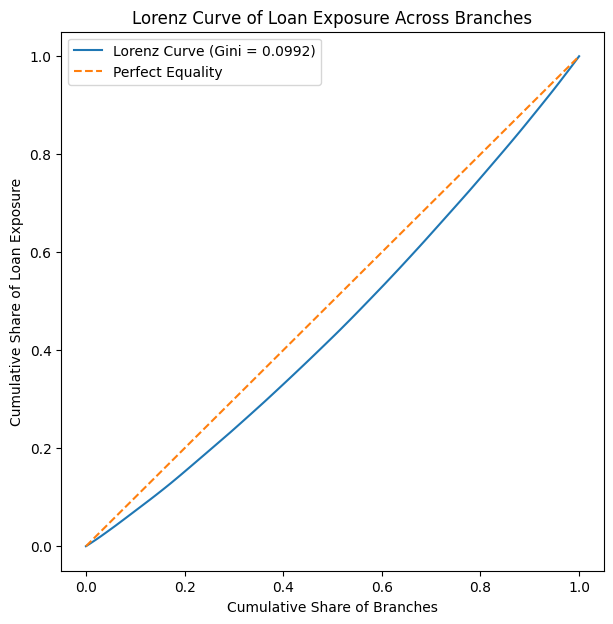


Branch Client Concentration Gini
   branch_id  client_gini
0          1         0.31
1          2         0.33
2          3         0.32
3          4         0.41
4          5         0.32


In [6]:
# =========================
# 6. Lorenz Curve + Gini (Branch Loan Exposure)
# =========================
branch_exposure = pd.read_sql_query("""
SELECT
    branch_id,
    SUM(loan_amount) AS branch_loan_exposure
FROM bank_transactions
GROUP BY branch_id
ORDER BY branch_loan_exposure
""", conn)

exposures = np.sort(branch_exposure["branch_loan_exposure"].values)

cum_exposure = np.cumsum(exposures)
cum_exposure = np.insert(cum_exposure, 0, 0)
cum_exposure = cum_exposure / cum_exposure[-1]

cum_branches = np.arange(0, len(exposures) + 1) / len(exposures)

gini = 1 - 2 * np.trapz(cum_exposure, cum_branches)
print(f"\nBranch Exposure Gini: {gini:.4f}")

loan_lorenz_df = pd.DataFrame({
    "cumulative_branches": cum_branches,
    "cumulative_exposure": cum_exposure
})
loan_lorenz_df.to_csv("lorenz_curve_branch_exposure.csv", index=False)

plt.figure(figsize=(7, 7))
plt.plot(cum_branches, cum_exposure, label=f"Lorenz Curve (Gini = {gini:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Equality")
plt.xlabel("Cumulative Share of Branches")
plt.ylabel("Cumulative Share of Loan Exposure")
plt.title("Lorenz Curve of Loan Exposure Across Branches")
plt.legend()
plt.show()

# =========================
# 6B. Branch Client Concentration Gini
# =========================
# One transaction per customer in this dataset, so transaction_amount is used
# as a proxy for customer revenue contribution within each branch.

branch_client_gini_list = []

for branch, group in df.groupby("branch_id"):
    customer_values = (
        group.groupby("customer_id")["transaction_amount"]
        .sum()
        .sort_values()
        .values
    )

    if len(customer_values) < 2 or customer_values.sum() == 0:
        client_gini = 0
    else:
        cumvals = np.cumsum(customer_values)
        cumvals = np.insert(cumvals, 0, 0)
        cumvals = cumvals / cumvals[-1]
        x = np.arange(0, len(customer_values) + 1) / len(customer_values)
        client_gini = 1 - 2 * np.trapz(cumvals, x)

    branch_client_gini_list.append({
        "branch_id": branch,
        "client_gini": client_gini
    })

branch_client_gini = pd.DataFrame(branch_client_gini_list)
branch_client_gini.to_csv("branch_client_gini.csv", index=False)

print("\nBranch Client Concentration Gini")
print(branch_client_gini.head())



In [7]:
# =========================
# 7. Borrower Leverage Risk (CCU)
# =========================
Branch_CCU = pd.read_sql_query("""
SELECT
    branch_id,
    COUNT(*) AS total_accounts,
    AVG(credit_card_balance * 1.0 / credit_limit) AS avg_ccu
FROM bank_transactions
WHERE credit_limit > 0
GROUP BY branch_id
ORDER BY avg_ccu DESC
""", conn)

Branch_CCU.to_csv("branch_ccu_summary.csv", index=False)
print("\nBranch CCU")
print(Branch_CCU.head())




Branch CCU
   branch_id  total_accounts  avg_ccu
0          3              52     0.85
1         64              40     0.84
2         77              51     0.82
3         36              50     0.80
4         79              42     0.79


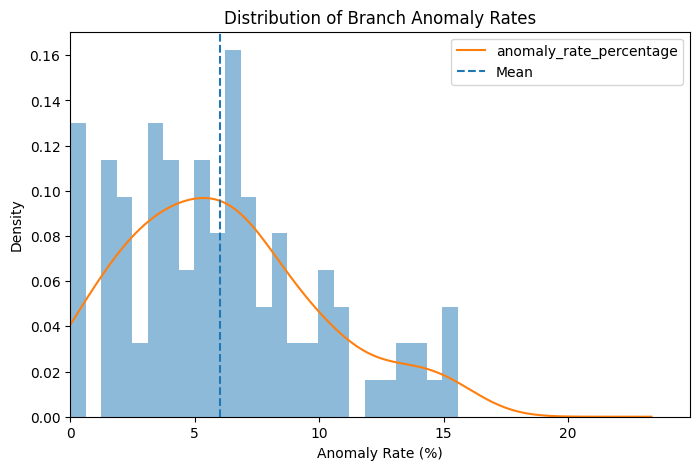

In [8]:
# =========================
# 8. Operational Anomaly Analysis
# =========================
Top_Anomaly_Rate_Branches = pd.read_sql_query("""
SELECT
    branch_id,
    COUNT(*) AS total_transactions,
    SUM(CASE WHEN anomaly = -1 THEN 1 ELSE 0 END) AS anomalous_transactions,
    ROUND(
        100.0 * SUM(CASE WHEN anomaly = -1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS anomaly_rate_percentage
FROM bank_transactions
GROUP BY branch_id
ORDER BY anomaly_rate_percentage DESC
""", conn)

Top_Anomaly_Rate_Branches["anomaly_percentile"] = (
    Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].rank(pct=True) * 100
)

Top_Anomaly_Rate_Branches["anomaly_z"] = (
    Top_Anomaly_Rate_Branches["anomaly_rate_percentage"]
    - Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].mean()
) / Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].std()

Top_Anomaly_Rate_Branches.to_csv("Top_Anomaly_Rate_Branches.csv", index=False)

plt.figure(figsize=(8, 5))
Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].hist(bins=25, density=True, alpha=0.5)
Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].plot(kind="kde")
plt.xlabel("Anomaly Rate (%)")
plt.xlim(left=0)
plt.title("Distribution of Branch Anomaly Rates")
plt.axvline(
    Top_Anomaly_Rate_Branches["anomaly_rate_percentage"].mean(),
    linestyle="--",
    label="Mean"
)
plt.legend()
plt.show()



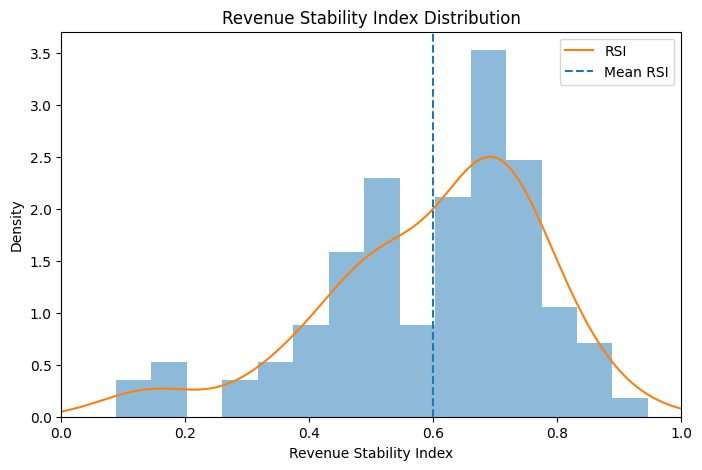

In [9]:
# =========================
# 9. Branch Operational Stability (RSI)
# =========================
branch_metrics = pd.read_sql_query("""
SELECT
    branch_id,
    COUNT(*) AS transactions,
    AVG(transaction_amount) AS avg_transaction,
    AVG(credit_limit) AS avg_credit_limit,
    AVG(credit_card_balance * 1.0 / credit_limit) AS avg_ccu,
    AVG(account_balance) AS avg_account_balance,
    AVG(interest_rate) AS avg_interest_rate,
    SUM(CASE WHEN anomaly = -1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS anomaly_rate
FROM bank_transactions
GROUP BY branch_id
""", conn)

tx_std = df.groupby("branch_id")["transaction_amount"].std().reset_index()
tx_std.columns = ["branch_id", "std_transaction"]

branch_metrics = branch_metrics.merge(tx_std, on="branch_id", how="left")

branch_metrics["transaction_cv"] = (
    branch_metrics["std_transaction"] /
    branch_metrics["avg_transaction"].replace(0, np.nan)
)

branch_metrics["cv_norm"] = (
    branch_metrics["transaction_cv"] - branch_metrics["transaction_cv"].min()
) / (
    branch_metrics["transaction_cv"].max() - branch_metrics["transaction_cv"].min()
)

branch_metrics["anomaly_norm"] = (
    branch_metrics["anomaly_rate"] - branch_metrics["anomaly_rate"].min()
) / (
    branch_metrics["anomaly_rate"].max() - branch_metrics["anomaly_rate"].min()
)

branch_metrics["ccu_norm"] = (
    branch_metrics["avg_ccu"] - branch_metrics["avg_ccu"].min()
) / (
    branch_metrics["avg_ccu"].max() - branch_metrics["avg_ccu"].min()
)

branch_metrics["RSI"] = 1 - (
    branch_metrics["cv_norm"] +
    branch_metrics["anomaly_norm"]
) / 2

plt.figure(figsize=(8, 5))
branch_metrics["RSI"].hist(bins=15, density=True, alpha=0.5)
branch_metrics["RSI"].plot(kind="kde")
plt.xlim(left=0, right=1)
plt.xlabel("Revenue Stability Index")
plt.title("Revenue Stability Index Distribution")
plt.axvline(branch_metrics["RSI"].mean(), linestyle="--", label="Mean RSI")
plt.legend()
plt.show()



In [10]:
# =========================
# 10. Loan Mix by Branch (Wide)
# =========================
loan_mix_query = """
SELECT
    branch_id,
    loan_type,
    SUM(loan_amount) * 1.0 /
    SUM(SUM(loan_amount)) OVER (PARTITION BY branch_id) AS loan_share
FROM bank_transactions
GROUP BY branch_id, loan_type
"""

loan_mix = pd.read_sql_query(loan_mix_query, conn)

loan_mix_wide = loan_mix.pivot(
    index="branch_id",
    columns="loan_type",
    values="loan_share"
).reset_index()

loan_mix_wide = loan_mix_wide.rename(columns={
    "Mortgage": "mortgage_share",
    "Auto": "auto_share",
    "Personal": "personal_share"
})



In [11]:
# =========================
# 11. Merge Final Branch Feature Table
# =========================
branch_metrics = branch_metrics.merge(
    HHI_branch,
    on="branch_id",
    how="left"
)

branch_metrics = branch_metrics.merge(
    loan_mix_wide,
    on="branch_id",
    how="left"
)

branch_metrics = branch_metrics.merge(
    branch_client_gini,
    on="branch_id",
    how="left"
)

branch_metrics = branch_metrics.loc[:, ~branch_metrics.columns.duplicated()]

# Remove circular normalized inputs that were used to construct RSI
circular_features = ["anomaly_norm", "cv_norm", "ccu_norm"]
branch_metrics = branch_metrics.drop(
    columns=[c for c in circular_features if c in branch_metrics.columns],
    errors="ignore"
)

branch_metrics.to_csv("branch_metrics_master.csv", index=False)

print("\nFinal Branch Metrics Columns")
print(branch_metrics.columns.tolist())



Final Branch Metrics Columns
['branch_id', 'transactions', 'avg_transaction', 'avg_credit_limit', 'avg_ccu', 'avg_account_balance', 'avg_interest_rate', 'anomaly_rate', 'std_transaction', 'transaction_cv', 'RSI', 'branch_hhi', 'auto_share', 'mortgage_share', 'personal_share', 'client_gini']


In [12]:
# =========================
# 11A. Interest Revenue + Loan Status Update
# =========================
# Uses the raw transaction-level dataframe preserved as bank_data

loan_df = bank_data.copy()

# Standardize interest rate to decimal form if stored as whole percent
loan_df["interest_rate_decimal"] = np.where(
    loan_df["interest_rate"] > 1,
    loan_df["interest_rate"] / 100,
    loan_df["interest_rate"]
)

# Approximate annualized interest revenue from approved loans only
approved_loans = loan_df[loan_df["loan_status"].astype(str).str.lower() == "approved"].copy()
approved_loans["interest_revenue"] = (
    approved_loans["loan_amount"] * approved_loans["interest_rate_decimal"]
)

branch_interest = (
    approved_loans.groupby("branch_id")["interest_revenue"]
    .sum()
    .reset_index()
)

# Loan status counts by branch
loan_status_counts = (
    loan_df.groupby(["branch_id", "loan_status"])
    .size()
    .unstack(fill_value=0)
)

loan_status_counts.columns = [
    f"loan_{str(c).strip().lower()}_count" for c in loan_status_counts.columns
]
loan_status_counts = loan_status_counts.reset_index()

# Merge into branch metrics
branch_metrics = branch_metrics.merge(
    branch_interest,
    on="branch_id",
    how="left"
)

branch_metrics = branch_metrics.merge(
    loan_status_counts,
    on="branch_id",
    how="left"
)

status_cols = [c for c in branch_metrics.columns if c.startswith("loan_") and c.endswith("_count")]
for col in status_cols:
    branch_metrics[col] = branch_metrics[col].fillna(0)

branch_metrics["interest_revenue"] = branch_metrics["interest_revenue"].fillna(0)

branch_metrics["loan_applications"] = branch_metrics[status_cols].sum(axis=1)

if "loan_approved_count" in branch_metrics.columns:
    branch_metrics["loan_approval_rate"] = np.where(
        branch_metrics["loan_applications"] > 0,
        branch_metrics["loan_approved_count"] / branch_metrics["loan_applications"],
        np.nan
    )

if "loan_rejected_count" in branch_metrics.columns:
    branch_metrics["loan_rejection_rate"] = np.where(
        branch_metrics["loan_applications"] > 0,
        branch_metrics["loan_rejected_count"] / branch_metrics["loan_applications"],
        np.nan
    )

if "loan_closed_count" in branch_metrics.columns:
    branch_metrics["loan_closed_rate"] = np.where(
        branch_metrics["loan_applications"] > 0,
        branch_metrics["loan_closed_count"] / branch_metrics["loan_applications"],
        np.nan
    )

# Estimated transaction revenue proxy
if "estimated_revenue" not in branch_metrics.columns:
    branch_metrics["estimated_revenue"] = (
        branch_metrics["avg_transaction"] * branch_metrics["transactions"]
    )

# Total revenue combines transaction activity proxy + interest revenue
branch_metrics["total_revenue"] = (
    branch_metrics["estimated_revenue"] + branch_metrics["interest_revenue"]
)

# Total risk-adjusted return
branch_metrics["RAR_total"] = (
    branch_metrics["total_revenue"] / (1 - branch_metrics["RSI"] + 0.01)
)

print("\nBranch Revenue + Loan Status Preview")
preview_cols = [
    "branch_id",
    "estimated_revenue",
    "interest_revenue",
    "total_revenue",
    "loan_applications"
]
preview_cols += [c for c in ["loan_approval_rate", "loan_rejection_rate", "loan_closed_rate"] if c in branch_metrics.columns]
print(branch_metrics[preview_cols].head())

# Optional save of enriched branch dataset
branch_metrics.to_csv("branch_metrics_enriched.csv", index=False)



Branch Revenue + Loan Status Preview
   branch_id  estimated_revenue  interest_revenue  total_revenue  loan_applications  loan_approval_rate  loan_rejection_rate  \
0          1         165,100.30         32,666.21     197,766.51                 59                0.42                 0.29   
1          2          99,175.36         12,196.62     111,371.98                 40                0.28                 0.38   
2          3         125,804.03         11,754.58     137,558.61                 52                0.23                 0.42   
3          4          91,467.63         15,640.96     107,108.59                 45                0.36                 0.29   
4          5         113,793.77         13,341.24     127,135.01                 45                0.27                 0.38   

   loan_closed_rate  
0              0.29  
1              0.35  
2              0.35  
3              0.36  
4              0.36  


In [14]:
# =========================
# 11B. Loan Approval Funnel by Branch
# =========================

branch_metrics = branch_metrics.copy()
loan_df = bank_data.copy()

# -----------------------------------------------------
# A. Safely identify raw columns
# -----------------------------------------------------
def find_col(df, candidates):
    lower_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        cand_key = cand.lower().strip()
        if cand_key in lower_map:
            return lower_map[cand_key]
    for c in df.columns:
        c_low = c.lower().strip()
        for cand in candidates:
            if cand.lower().strip() in c_low:
                return c
    return None

branch_col = find_col(loan_df, ["Branch ID", "branch_id"])
loan_amount_col = find_col(loan_df, ["Loan Amount", "loan_amount"])
loan_status_col = find_col(loan_df, ["Loan Status", "loan_status"])
interest_rate_col = find_col(loan_df, ["Interest Rate", "interest_rate"])

required = {
    "branch": branch_col,
    "loan_amount": loan_amount_col,
    "loan_status": loan_status_col,
    "interest_rate": interest_rate_col
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns for loan funnel: {missing}")

# -----------------------------------------------------
# B. Standardize fields
# -----------------------------------------------------
loan_df = loan_df.copy()
loan_df["loan_status_clean"] = loan_df[loan_status_col].astype(str).str.strip().str.lower()

loan_df["interest_rate_decimal"] = np.where(
    loan_df[interest_rate_col] > 1,
    loan_df[interest_rate_col] / 100,
    loan_df[interest_rate_col]
)

loan_df["potential_interest_revenue"] = (
    loan_df[loan_amount_col] * loan_df["interest_rate_decimal"]
)

# -----------------------------------------------------
# C. Define status buckets
# -----------------------------------------------------
approved_statuses = {"approved", "funded", "closed"}
rejected_statuses = {"rejected", "denied", "declined"}

loan_df["is_approved"] = loan_df["loan_status_clean"].isin(approved_statuses).astype(int)
loan_df["is_rejected"] = loan_df["loan_status_clean"].isin(rejected_statuses).astype(int)

# -----------------------------------------------------
# D. Revenue buckets
# -----------------------------------------------------
loan_df["approved_interest_revenue"] = np.where(
    loan_df["is_approved"] == 1,
    loan_df["potential_interest_revenue"],
    0
)

loan_df["rejected_interest_revenue"] = np.where(
    loan_df["is_rejected"] == 1,
    loan_df["potential_interest_revenue"],
    0
)

# -----------------------------------------------------
# E. Branch-level funnel table
# -----------------------------------------------------
branch_funnel = (
    loan_df.groupby(branch_col)
    .agg(
        loan_applications=(loan_amount_col, "count"),
        total_possible_loan_amount=(loan_amount_col, "sum"),
        total_possible_interest_revenue=("potential_interest_revenue", "sum"),
        approved_loan_count=("is_approved", "sum"),
        rejected_loan_count=("is_rejected", "sum"),
        approved_loan_amount=(loan_amount_col, lambda s: s[loan_df.loc[s.index, "is_approved"] == 1].sum()),
        rejected_loan_amount=(loan_amount_col, lambda s: s[loan_df.loc[s.index, "is_rejected"] == 1].sum()),
        approved_interest_revenue=("approved_interest_revenue", "sum"),
        rejected_interest_revenue=("rejected_interest_revenue", "sum")
    )
    .reset_index()
)

branch_funnel = branch_funnel.rename(columns={branch_col: "branch_id"})

# -----------------------------------------------------
# F. Funnel rates / efficiency metrics
# -----------------------------------------------------
branch_funnel["approval_rate"] = np.where(
    branch_funnel["loan_applications"] > 0,
    branch_funnel["approved_loan_count"] / branch_funnel["loan_applications"],
    np.nan
)

branch_funnel["rejection_rate"] = np.where(
    branch_funnel["loan_applications"] > 0,
    branch_funnel["rejected_loan_count"] / branch_funnel["loan_applications"],
    np.nan
)

branch_funnel["revenue_capture_rate"] = np.where(
    branch_funnel["total_possible_interest_revenue"] > 0,
    branch_funnel["approved_interest_revenue"] / branch_funnel["total_possible_interest_revenue"],
    np.nan
)

branch_funnel["revenue_loss_rate"] = np.where(
    branch_funnel["total_possible_interest_revenue"] > 0,
    branch_funnel["rejected_interest_revenue"] / branch_funnel["total_possible_interest_revenue"],
    np.nan
)

branch_funnel["avg_potential_revenue_per_application"] = np.where(
    branch_funnel["loan_applications"] > 0,
    branch_funnel["total_possible_interest_revenue"] / branch_funnel["loan_applications"],
    np.nan
)

# -----------------------------------------------------
# G. Merge into branch_metrics
# -----------------------------------------------------
branch_metrics = branch_metrics.copy()

# Make sure merge keys match type
branch_metrics["branch_id"] = branch_metrics["branch_id"].astype(str)
branch_funnel["branch_id"] = branch_funnel["branch_id"].astype(str)

# Drop any old funnel columns / overlapping columns before merge
funnel_cols_to_drop = [
    "loan_applications",
    "loan_applications_x",
    "loan_applications_y",
    "total_possible_loan_amount",
    "total_possible_interest_revenue",
    "approved_loan_count",
    "rejected_loan_count",
    "approved_loan_amount",
    "rejected_loan_amount",
    "approved_interest_revenue",
    "rejected_interest_revenue",
    "approval_rate",
    "rejection_rate",
    "revenue_capture_rate",
    "revenue_loss_rate",
    "avg_potential_revenue_per_application"
]

existing_funnel_cols = [c for c in funnel_cols_to_drop if c in branch_metrics.columns]
if existing_funnel_cols:
    branch_metrics = branch_metrics.drop(columns=existing_funnel_cols)

branch_metrics = branch_metrics.merge(
    branch_funnel,
    on="branch_id",
    how="left"
)

# Optional alignment with prior naming
branch_metrics["loan_approval_rate"] = branch_metrics["approval_rate"]
branch_metrics["loan_rejection_rate"] = branch_metrics["rejection_rate"]

# -----------------------------------------------------
# H. Preview
# -----------------------------------------------------
preview_cols = [
    "branch_id",
    "loan_applications",
    "approved_loan_count",
    "rejected_loan_count",
    "approval_rate",
    "revenue_capture_rate",
    "total_possible_interest_revenue",
    "approved_interest_revenue",
    "rejected_interest_revenue"
]

existing_preview_cols = [c for c in preview_cols if c in branch_metrics.columns]

print("\nLoan Approval Funnel Preview")
print(branch_metrics[existing_preview_cols].head())

branch_funnel.to_csv("branch_loan_approval_funnel.csv", index=False)



Loan Approval Funnel Preview
  branch_id  loan_applications  approved_loan_count  rejected_loan_count  approval_rate  revenue_capture_rate  \
0         1                 59                   42                   17           0.71                  0.66   
1         2                 40                   25                   15           0.62                  0.65   
2         3                 52                   30                   22           0.58                  0.57   
3         4                 45                   32                   13           0.71                  0.68   
4         5                 45                   28                   17           0.62                  0.62   

   total_possible_interest_revenue  approved_interest_revenue  rejected_interest_revenue  
0                        82,075.51                  54,515.73                  27,559.77  
1                        45,470.54                  29,520.19                  15,950.35  
2                 


Non-Circular Correlation with RSI
client_gini                             -0.69
revenue_capture_rate                    -0.13
avg_potential_revenue_per_application   -0.12
personal_share                          -0.10
mortgage_share                          -0.09
approved_interest_revenue               -0.08
interest_revenue                        -0.06
loan_approval_rate                      -0.06
loan_closed_rate                        -0.06
branch_hhi                              -0.04
total_possible_interest_revenue         -0.03
avg_interest_rate                       -0.02
avg_account_balance                      0.04
loan_rejection_rate                      0.06
transactions                             0.07
avg_credit_limit                         0.07
rejected_interest_revenue                0.07
revenue_loss_rate                        0.13
auto_share                               0.18
avg_transaction                          0.59
Name: RSI, dtype: float64


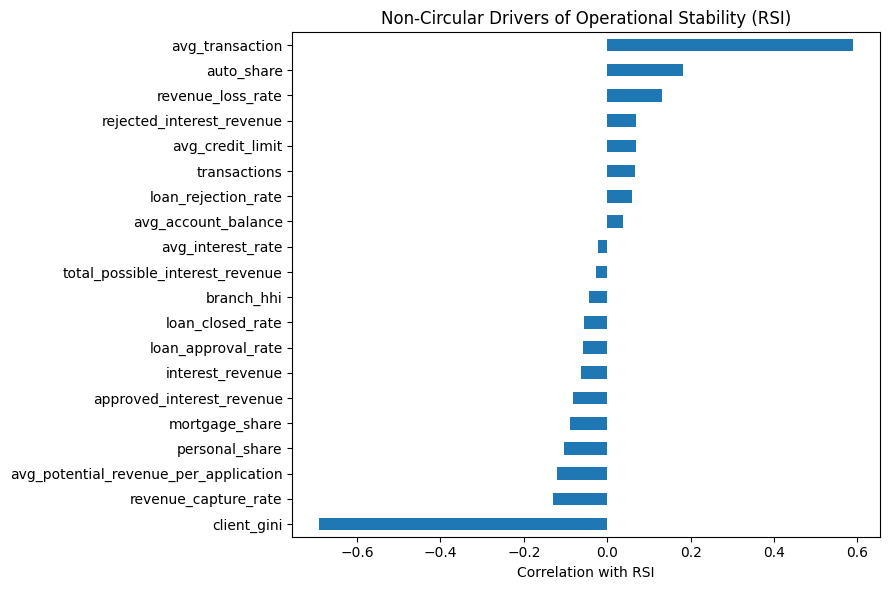

In [15]:
# =========================
# 12. Non-Circular RSI Driver Analysis
# =========================
candidate_vars = [
    "client_gini",
    "branch_hhi",
    "auto_share",
    "mortgage_share",
    "personal_share",
    "avg_transaction",
    "transactions",
    "avg_credit_limit",
    "avg_account_balance",
    "avg_interest_rate",
    "interest_revenue",
    "loan_approval_rate",
    "loan_rejection_rate",
    "loan_closed_rate",
    "total_possible_interest_revenue",
    "approved_interest_revenue",
    "rejected_interest_revenue",
    "revenue_capture_rate",
    "revenue_loss_rate",
    "avg_potential_revenue_per_application"
]


available_vars = [c for c in candidate_vars if c in branch_metrics.columns]

corr_rsi = (
    branch_metrics[available_vars + ["RSI"]]
    .corr(numeric_only=True)["RSI"]
    .drop("RSI")
    .round(3)
    .sort_values()
)

print("\nNon-Circular Correlation with RSI")
print(corr_rsi)

plt.figure(figsize=(9, 6))
corr_rsi.plot(kind="barh")
plt.title("Non-Circular Drivers of Operational Stability (RSI)")
plt.xlabel("Correlation with RSI")
plt.tight_layout()
plt.show()


In [16]:
# =========================
# 13. Branch Risk Table for Frontier
# =========================
Branch_Risk = HHI_branch.merge(Branch_CCU, on="branch_id", how="left")

Branch_Risk["branch_hhi"] = pd.to_numeric(Branch_Risk["branch_hhi"], errors="coerce")
Branch_Risk["avg_ccu"] = pd.to_numeric(Branch_Risk["avg_ccu"], errors="coerce")

Branch_Risk["HHI_z"] = (
    Branch_Risk["branch_hhi"] - Branch_Risk["branch_hhi"].mean()
) / Branch_Risk["branch_hhi"].std()

Branch_Risk["CCU_z"] = (
    Branch_Risk["avg_ccu"] - Branch_Risk["avg_ccu"].mean()
) / Branch_Risk["avg_ccu"].std()

Branch_Risk["risk_score"] = Branch_Risk["HHI_z"] + Branch_Risk["CCU_z"].clip(lower=0)



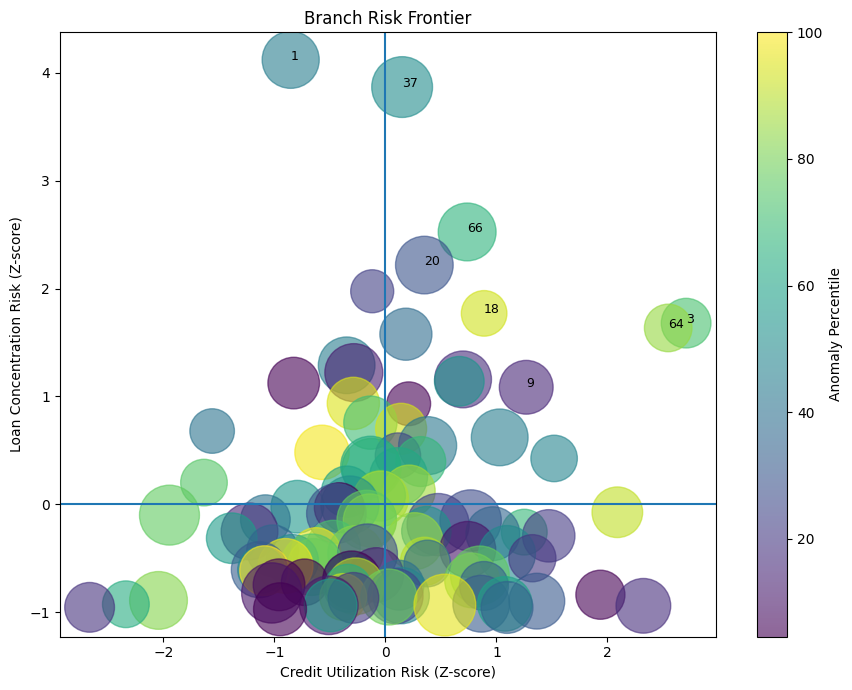

In [18]:
# =========================
# 14. Risk Frontier Dataset
# =========================

# Make safe copies
branch_risk_rf = Branch_Risk.copy()
branch_exposure_rf = branch_exposure.copy()
top_anomaly_rf = Top_Anomaly_Rate_Branches.copy()
branch_metrics_rf = branch_metrics.copy()

# Standardize merge key types
for df in [branch_risk_rf, branch_exposure_rf, top_anomaly_rf, branch_metrics_rf]:
    df["branch_id"] = df["branch_id"].astype(str)

Risk_Frontier = (
    branch_risk_rf.merge(
        branch_exposure_rf,
        on="branch_id",
        how="left"
    )
    .merge(
        top_anomaly_rf[["branch_id", "anomaly_percentile"]],
        on="branch_id",
        how="left"
    )
    .merge(
        branch_metrics_rf[["branch_id", "RSI", "client_gini"]],
        on="branch_id",
        how="left"
    )
)

Risk_Frontier["risk_score"] = pd.to_numeric(Risk_Frontier["risk_score"], errors="coerce")
Risk_Frontier["branch_loan_exposure"] = pd.to_numeric(Risk_Frontier["branch_loan_exposure"], errors="coerce")
Risk_Frontier["CCU_z"] = pd.to_numeric(Risk_Frontier["CCU_z"], errors="coerce")
Risk_Frontier["HHI_z"] = pd.to_numeric(Risk_Frontier["HHI_z"], errors="coerce")
Risk_Frontier["anomaly_percentile"] = pd.to_numeric(Risk_Frontier["anomaly_percentile"], errors="coerce")

Risk_Frontier.to_csv("branch_risk_frontier.csv", index=False)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    Risk_Frontier["CCU_z"],
    Risk_Frontier["HHI_z"],
    s=Risk_Frontier["branch_loan_exposure"] / Risk_Frontier["branch_loan_exposure"].max() * 2000,
    c=Risk_Frontier["anomaly_percentile"],
    alpha=0.6
)
plt.axhline(0)
plt.axvline(0)

top_labels = Risk_Frontier.sort_values("risk_score", ascending=False).head(8)
for _, row in top_labels.iterrows():
    plt.text(row["CCU_z"], row["HHI_z"], str(row["branch_id"]), fontsize=9)

plt.xlabel("Credit Utilization Risk (Z-score)")
plt.ylabel("Loan Concentration Risk (Z-score)")
plt.title("Branch Risk Frontier")
cbar = plt.colorbar(scatter)
cbar.set_label("Anomaly Percentile")
plt.tight_layout()
plt.show()


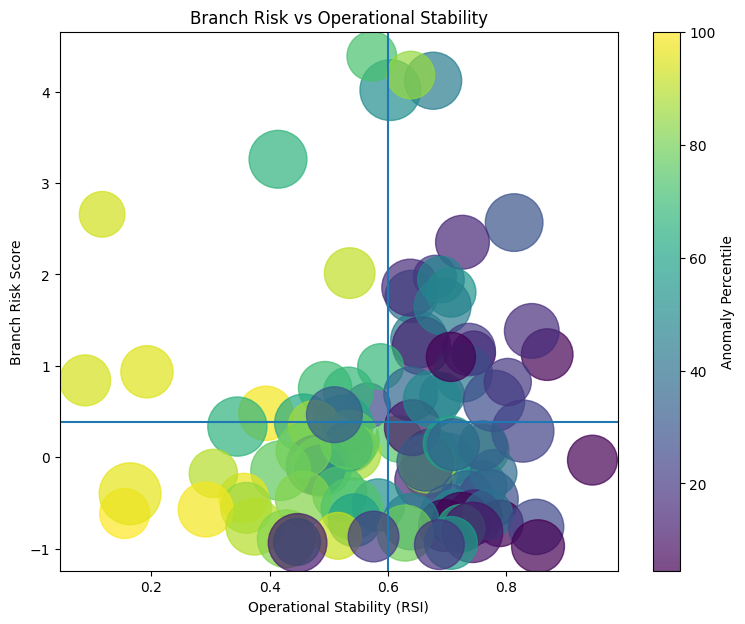

In [19]:
# =========================
# 15. Risk vs Stability Frontier
# =========================
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    Risk_Frontier["RSI"],
    Risk_Frontier["risk_score"],
    s=Risk_Frontier["branch_loan_exposure"] / Risk_Frontier["branch_loan_exposure"].max() * 2000,
    c=Risk_Frontier["anomaly_percentile"],
    alpha=0.7
)

plt.axvline(Risk_Frontier["RSI"].mean())
plt.axhline(Risk_Frontier["risk_score"].mean())

plt.xlabel("Operational Stability (RSI)")
plt.ylabel("Branch Risk Score")
plt.title("Branch Risk vs Operational Stability")
plt.colorbar(scatter, label="Anomaly Percentile")
plt.show()




Risk Contribution Table
  branch_id  branch_hhi  total_accounts  avg_ccu  HHI_z  CCU_z  risk_score  branch_loan_exposure  anomaly_percentile  RSI  client_gini  \
0        37        0.42              52     0.64   3.87   0.15        4.02          1,664,663.55               51.01 0.60         0.33   
1         1        0.42              59     0.56   4.12  -0.85        4.12          1,467,285.24               44.44 0.68         0.31   
2        66        0.39              56     0.69   2.52   0.74        3.26          1,507,027.33               66.16 0.41         0.37   
3         3        0.38              52     0.85   1.68   2.71        4.39          1,110,782.74               72.22 0.57         0.32   
4        64        0.38              40     0.84   1.63   2.55        4.18          1,019,368.22               84.85 0.64         0.28   
5        20        0.39              57     0.66   2.22   0.35        2.57          1,496,124.14               28.79 0.81         0.29   
6        

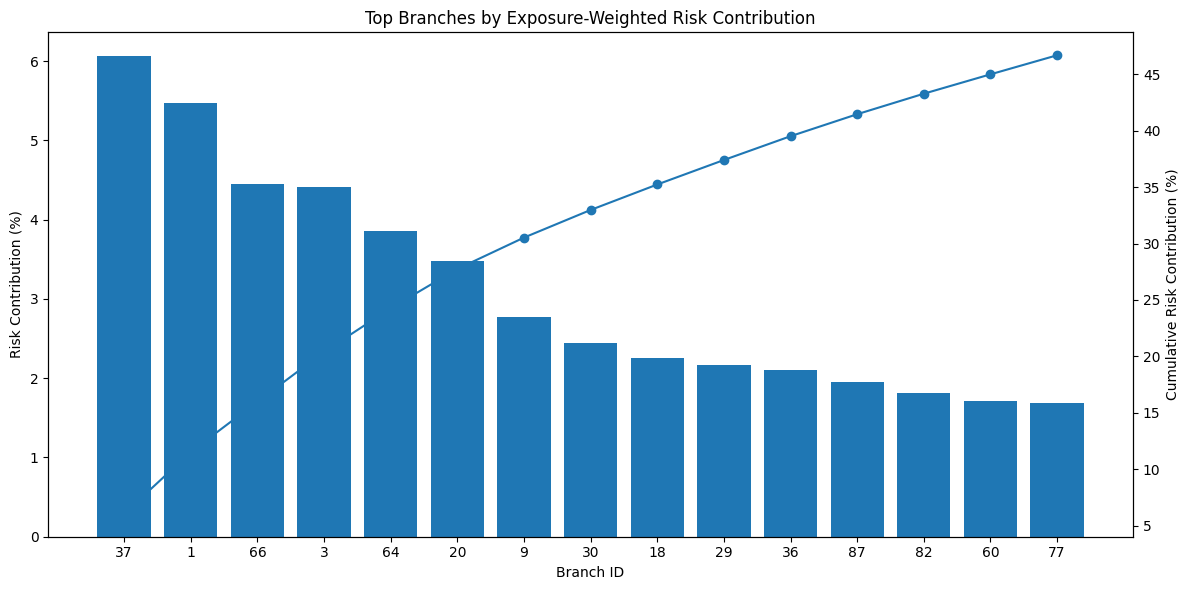

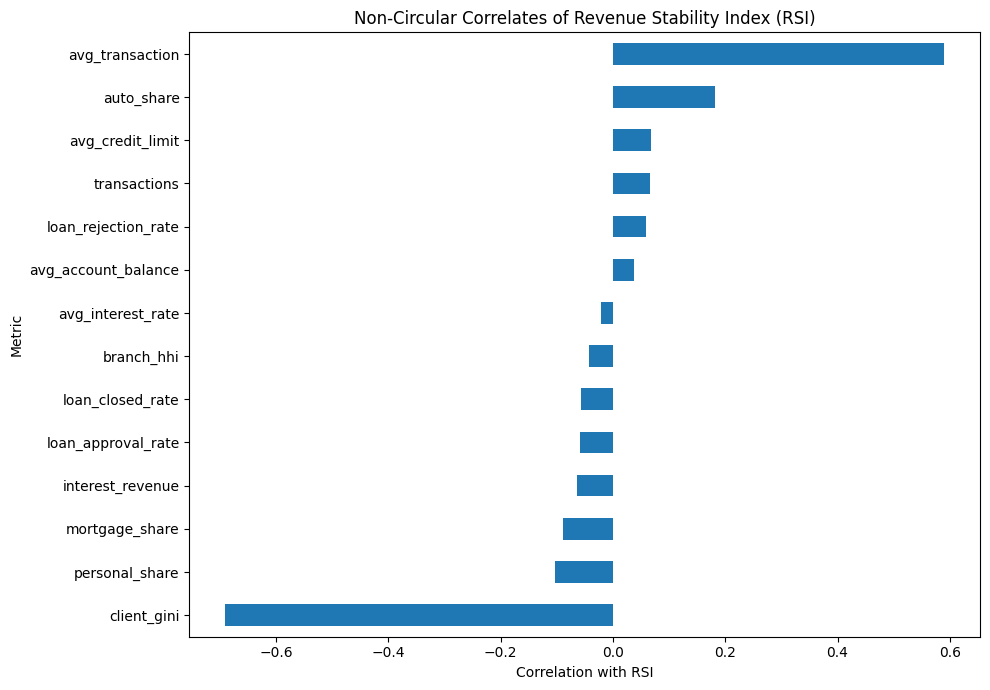


Non-Circular Correlation with RSI
client_gini           -0.69
personal_share        -0.10
mortgage_share        -0.09
interest_revenue      -0.06
loan_approval_rate    -0.06
loan_closed_rate      -0.06
branch_hhi            -0.04
avg_interest_rate     -0.02
avg_account_balance    0.04
loan_rejection_rate    0.06
transactions           0.07
avg_credit_limit       0.07
auto_share             0.18
avg_transaction        0.59
Name: RSI, dtype: float64

PCA Explained Variance
  component  explained_variance_ratio  cumulative_explained_variance
0       PC1                      0.39                           0.39
1       PC2                      0.32                           0.71
2       PC3                      0.29                           1.00

PCA Loadings
                 PC1   PC2   PC3
transaction_cv  0.66 -0.13  0.74
anomaly_rate    0.45  0.86 -0.25
avg_ccu        -0.60  0.50  0.63


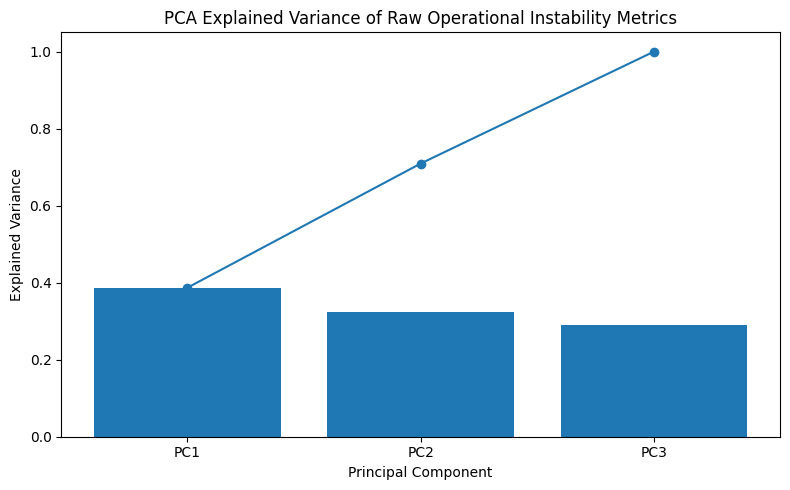


Correlation between RSI and PCA factor: 0.8023


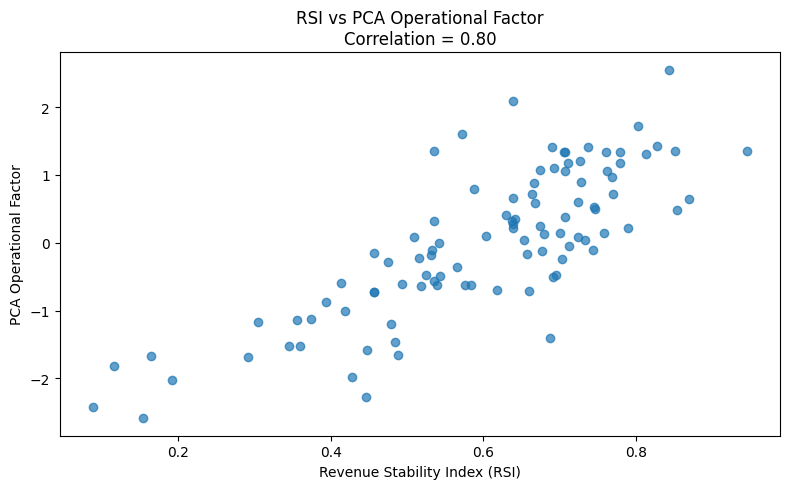

In [20]:
# =========================
# 16. Exposure-Weighted Risk Contribution
# =========================
Risk_Frontier = Risk_Frontier.copy()
branch_metrics = branch_metrics.copy()

Risk_Frontier["exposure_weighted_risk"] = (
    Risk_Frontier["risk_score"] *
    Risk_Frontier["branch_loan_exposure"]
)

risk_denominator = Risk_Frontier["exposure_weighted_risk"].abs().sum()
Risk_Frontier["risk_contribution_percent"] = np.where(
    risk_denominator != 0,
    (Risk_Frontier["exposure_weighted_risk"] / risk_denominator) * 100,
    np.nan
)

Risk_Contribution_Table = Risk_Frontier.sort_values(
    "risk_contribution_percent",
    ascending=False
).reset_index(drop=True)

Risk_Contribution_Table["cumulative_risk"] = (
    Risk_Contribution_Table["risk_contribution_percent"].cumsum()
)

Risk_Contribution_Table.to_csv("branch_risk_contribution.csv", index=False)

print("\nRisk Contribution Table")
print(Risk_Contribution_Table.head(10))

# =========================
# 16A. Pareto Chart: Exposure-Weighted Branch Risk Contribution
# =========================
top_n = min(15, len(Risk_Contribution_Table))
plot_df = Risk_Contribution_Table.head(top_n).copy()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    plot_df["branch_id"].astype(str),
    plot_df["risk_contribution_percent"]
)
ax1.set_xlabel("Branch ID")
ax1.set_ylabel("Risk Contribution (%)")
ax1.set_title("Top Branches by Exposure-Weighted Risk Contribution")

ax2 = ax1.twinx()
ax2.plot(
    plot_df["branch_id"].astype(str),
    plot_df["cumulative_risk"],
    marker="o"
)
ax2.set_ylabel("Cumulative Risk Contribution (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 16B. Non-Circular Correlation with RSI Chart
# =========================
candidate_vars = [
    "client_gini",
    "branch_hhi",
    "auto_share",
    "mortgage_share",
    "personal_share",
    "avg_transaction",
    "transactions",
    "avg_credit_limit",
    "avg_account_balance",
    "avg_interest_rate",
    "interest_revenue",
    "loan_approval_rate",
    "loan_rejection_rate",
    "loan_closed_rate"
]
available_vars = [c for c in candidate_vars if c in branch_metrics.columns]

corr_with_rsi = (
    branch_metrics[available_vars + ["RSI"]]
    .corr(numeric_only=True)["RSI"]
    .drop("RSI")
    .sort_values()
)

plt.figure(figsize=(10, 7))
corr_with_rsi.plot(kind="barh")
plt.xlabel("Correlation with RSI")
plt.ylabel("Metric")
plt.title("Non-Circular Correlates of Revenue Stability Index (RSI)")
plt.tight_layout()
plt.show()

print("\nNon-Circular Correlation with RSI")
print(corr_with_rsi.round(3))

# =========================
# 17. PCA Validation of Operational Instability
# =========================
# Use raw operational metrics instead of normalized components
pca_cols = ["transaction_cv", "anomaly_rate", "avg_ccu"]
available_pca_cols = [col for col in pca_cols if col in branch_metrics.columns]

if len(available_pca_cols) >= 2:
    pca_features = branch_metrics[available_pca_cols].dropna().copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_features)

    pca = PCA(n_components=len(available_pca_cols))
    pca.fit(X_scaled)

    explained_var = pd.DataFrame({
        "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
    })

    loadings = pd.DataFrame(
        pca.components_.T,
        index=available_pca_cols,
        columns=[f"PC{i+1}" for i in range(len(available_pca_cols))]
    )

    print("\nPCA Explained Variance")
    print(explained_var.round(4))

    print("\nPCA Loadings")
    print(loadings.round(4))

    plt.figure(figsize=(8, 5))
    plt.bar(explained_var["component"], explained_var["explained_variance_ratio"])
    plt.plot(
        explained_var["component"],
        explained_var["cumulative_explained_variance"],
        marker="o"
    )
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance")
    plt.title("PCA Explained Variance of Raw Operational Instability Metrics")
    plt.tight_layout()
    plt.show()

    pca_1 = PCA(n_components=1)
    pca_factor = pca_1.fit_transform(X_scaled).flatten()

    pca_compare = pca_features.copy()
    pca_compare["pca_factor"] = pca_factor
    branch_metrics.loc[pca_compare.index, "pca_factor"] = pca_compare["pca_factor"]

    rsi_pca_corr = branch_metrics.loc[pca_compare.index, "RSI"].corr(
        branch_metrics.loc[pca_compare.index, "pca_factor"]
    )

    if rsi_pca_corr < 0:
        branch_metrics.loc[pca_compare.index, "pca_factor"] = (
            -branch_metrics.loc[pca_compare.index, "pca_factor"]
        )
        rsi_pca_corr = branch_metrics.loc[pca_compare.index, "RSI"].corr(
            branch_metrics.loc[pca_compare.index, "pca_factor"]
        )

    print(f"\nCorrelation between RSI and PCA factor: {rsi_pca_corr:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(
        branch_metrics.loc[pca_compare.index, "RSI"],
        branch_metrics.loc[pca_compare.index, "pca_factor"],
        alpha=0.7
    )
    plt.xlabel("Revenue Stability Index (RSI)")
    plt.ylabel("PCA Operational Factor")
    plt.title(f"RSI vs PCA Operational Factor\nCorrelation = {rsi_pca_corr:.2f}")
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping PCA: not enough raw operational metrics available.")


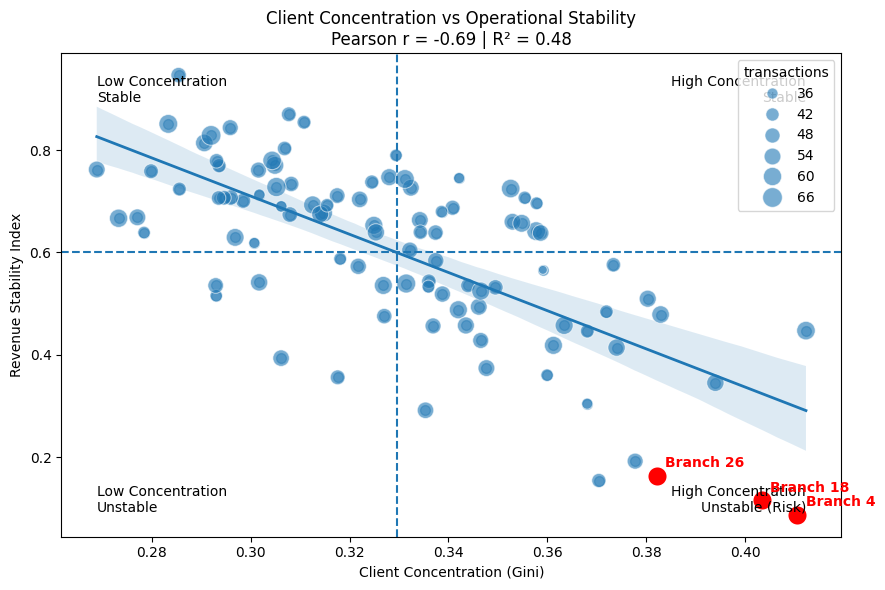

In [21]:
# Ensure columns exist and remove NaNs
df = branch_metrics.dropna(subset=["client_gini", "RSI"]).copy()

x = df["client_gini"]
y = df["RSI"]

plt.figure(figsize=(9,6))

# Regression line with confidence band
sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha":0.4, "s":50},
    line_kws={"linewidth":2},
    ci=95
)

# Quadrant lines (means)
x_mean = x.mean()
y_mean = y.mean()

plt.axvline(x_mean, linestyle="--")
plt.axhline(y_mean, linestyle="--")

# Quadrant labels
plt.text(x.min(), y.max(), "Low Concentration\nStable", ha="left", va="top")
plt.text(x.max(), y.max(), "High Concentration\nStable", ha="right", va="top")
plt.text(x.min(), y.min(), "Low Concentration\nUnstable", ha="left", va="bottom")
plt.text(x.max(), y.min(), "High Concentration\nUnstable (Risk)", ha="right", va="bottom")

# Correlation metrics
pearson = np.corrcoef(x, y)[0,1]
r2 = pearson**2

# Scatter plot sized by activity
sns.scatterplot(
    x="client_gini",
    y="RSI",
    size="transactions",
    sizes=(40,200),
    alpha=0.6,
    data=df
)

# -------- Risk Scoring --------

df["rsi_inverted"] = 1 - (df["RSI"] - df["RSI"].min()) / (df["RSI"].max() - df["RSI"].min())
df["risk_score"] = df["client_gini"] + df["rsi_inverted"]

top_risk = df.nlargest(3, "risk_score")

# Highlight risky branches
sns.scatterplot(
    data=top_risk,
    x="client_gini",
    y="RSI",
    color="red",
    s=200,
    legend=False
)

# Label them
for _, row in top_risk.iterrows():
    plt.annotate(
        f"Branch {int(row['branch_id'])}",
        (row["client_gini"], row["RSI"]),
        xytext=(6,6),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="red"
    )

plt.xlabel("Client Concentration (Gini)")
plt.ylabel("Revenue Stability Index")

plt.title(
    f"Client Concentration vs Operational Stability\n"
    f"Pearson r = {pearson:.2f} | R² = {r2:.2f}"
)

plt.tight_layout()
plt.show()


Correlation with Total Risk Adjusted Return
client_gini                 -0.52
mortgage_share              -0.13
loan_rejection_rate         -0.11
branch_hhi                  -0.03
avg_interest_rate           -0.03
personal_share              -0.03
avg_account_balance         -0.02
mortgage_interest_revenue    0.04
loan_approval_rate           0.06
loan_closed_rate             0.06
personal_interest_revenue    0.08
avg_credit_limit             0.11
auto_share                   0.13
interest_revenue             0.14
auto_interest_revenue        0.14
transactions                 0.26
avg_transaction              0.51
Name: RAR_total, dtype: float64


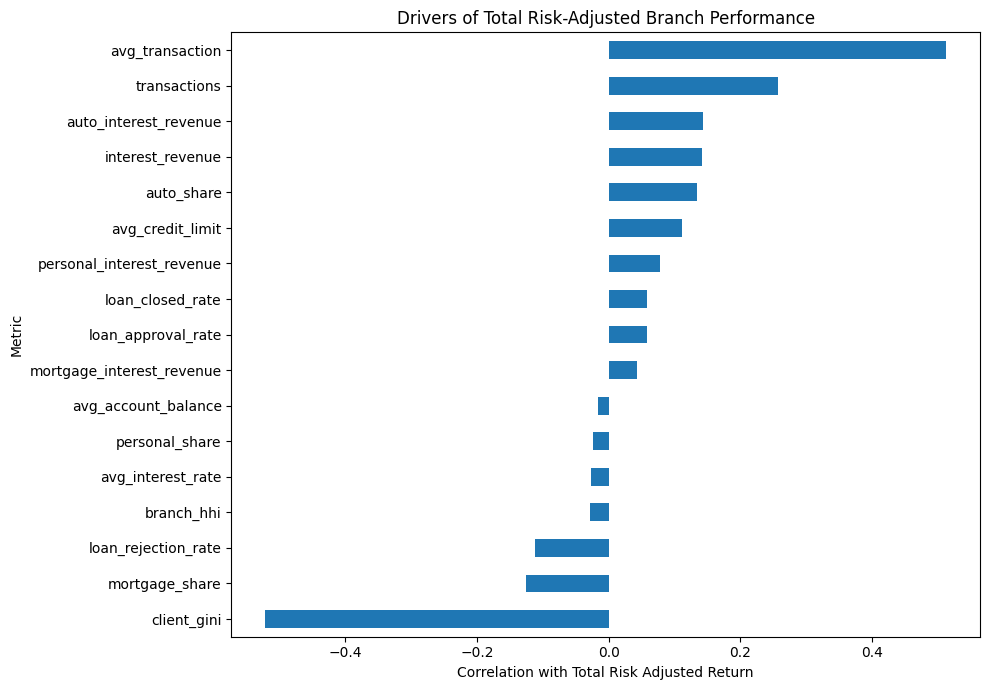


Interest Revenue Contribution by Loan Type
  loan_type  interest_revenue  revenue_share
1  mortgage      1,600,330.88           0.34
0      auto      1,579,816.41           0.34
2  personal      1,518,041.62           0.32


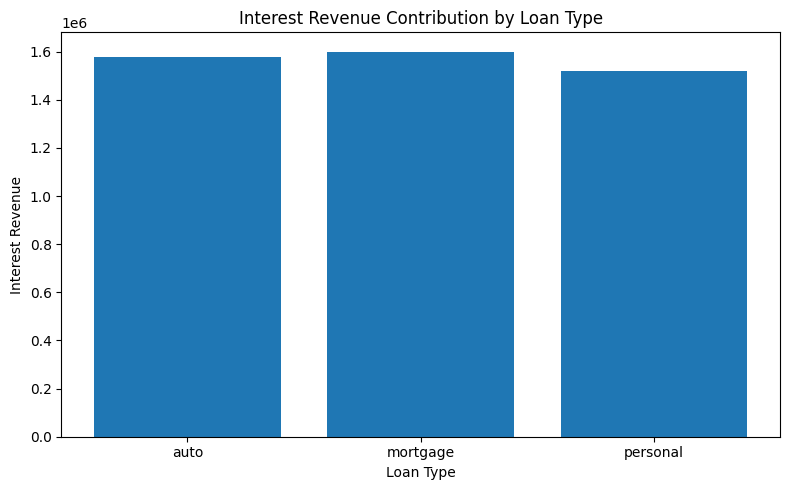

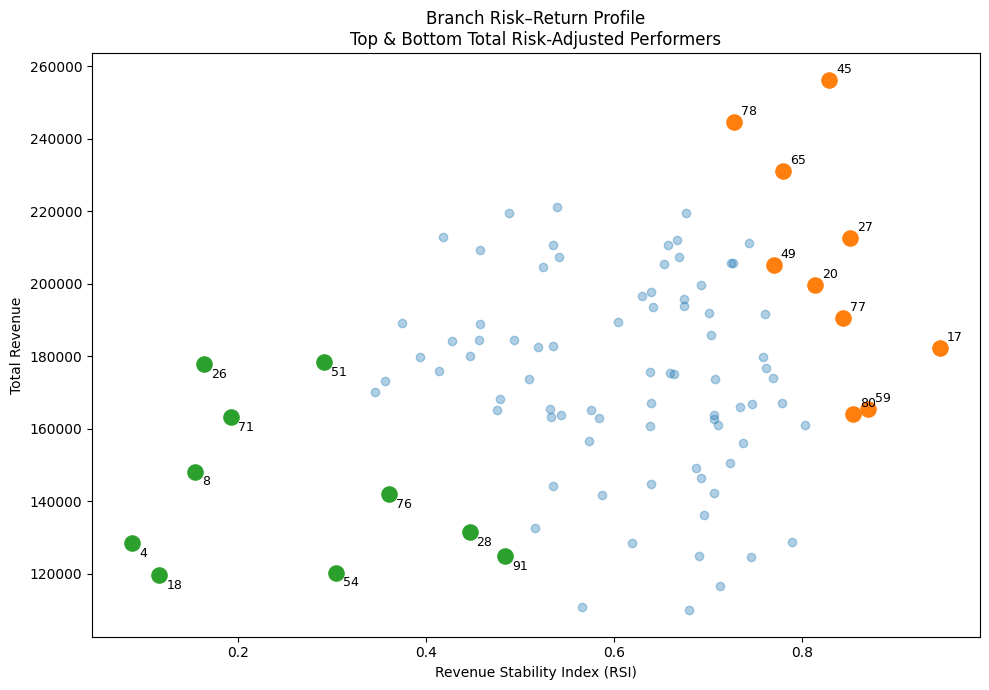


Top 10 Branches by Total Risk Adjusted Return
   branch_id  estimated_revenue  interest_revenue  mortgage_interest_revenue  auto_interest_revenue  personal_interest_revenue  \
16        17         138,146.22         44,171.30                  12,221.20              16,939.21                  15,010.89   
44        45         182,460.75         73,867.49                  18,356.39              33,367.28                  22,143.83   
26        27         163,955.59         48,695.28                  17,242.74              11,619.40                  19,833.14   
58        59         127,434.74         38,074.30                  19,325.90              10,872.45                   7,875.95   
76        77         142,333.30         48,269.39                  15,237.16              16,811.05                  16,221.18   
79        80         109,153.78         55,023.64                  15,605.19              20,418.17                  19,000.28   
19        20         156,234.79         43,

In [23]:
# =========================
# 18. Total Revenue + Loan-Type Revenue + Risk-Adjusted Return Analysis
# =========================

branch_metrics = branch_metrics.copy()

# -----------------------------------------------------
# A. Ensure bank_data exists
# -----------------------------------------------------
if "bank_data" not in globals():
    raise ValueError("bank_data is not defined. Make sure your raw dataframe is named bank_data.")

loan_df = bank_data.copy()

# -----------------------------------------------------
# B. Detect raw column names safely
# -----------------------------------------------------
def find_col(df, candidates):
    lower_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        cand_key = cand.lower().strip()
        if cand_key in lower_map:
            return lower_map[cand_key]
    for c in df.columns:
        c_low = c.lower().strip()
        for cand in candidates:
            if cand.lower().strip() in c_low:
                return c
    return None

branch_col = find_col(loan_df, ["Branch ID", "branch_id"])
loan_amount_col = find_col(loan_df, ["Loan Amount", "loan_amount"])
loan_type_col = find_col(loan_df, ["Loan Type", "loan_type"])
loan_status_col = find_col(loan_df, ["Loan Status", "loan_status"])
interest_rate_col = find_col(loan_df, ["Interest Rate", "interest_rate"])

required_cols = {
    "Branch ID": branch_col,
    "Loan Amount": loan_amount_col,
    "Loan Type": loan_type_col,
    "Loan Status": loan_status_col,
    "Interest Rate": interest_rate_col
}

missing = [k for k, v in required_cols.items() if v is None]
if missing:
    raise ValueError(
        f"Missing required columns in bank_data: {missing}\n"
        f"Available columns: {loan_df.columns.tolist()}"
    )

# -----------------------------------------------------
# C. Standardize data types and clean key fields
# -----------------------------------------------------
branch_metrics["branch_id"] = branch_metrics["branch_id"].astype(str)
loan_df[branch_col] = loan_df[branch_col].astype(str)

loan_df[loan_amount_col] = pd.to_numeric(loan_df[loan_amount_col], errors="coerce").fillna(0)
loan_df[interest_rate_col] = pd.to_numeric(loan_df[interest_rate_col], errors="coerce").fillna(0)

loan_df[loan_status_col] = loan_df[loan_status_col].astype(str).str.strip().str.lower()
loan_df[loan_type_col] = loan_df[loan_type_col].astype(str).str.strip().str.lower()

# Handle interest rate whether stored as 5.5 or 0.055
loan_df["interest_rate_decimal"] = np.where(
    loan_df[interest_rate_col] > 1,
    loan_df[interest_rate_col] / 100,
    loan_df[interest_rate_col]
)

loan_df["interest_revenue"] = loan_df[loan_amount_col] * loan_df["interest_rate_decimal"]

# Treat approved/funded/closed as revenue-generating if desired
approved_statuses = {"approved", "funded", "closed"}
approved_loans = loan_df[loan_df[loan_status_col].isin(approved_statuses)].copy()

# -----------------------------------------------------
# D. Branch-level total interest revenue
# -----------------------------------------------------
branch_interest = (
    approved_loans.groupby(branch_col, dropna=False)["interest_revenue"]
    .sum()
    .reset_index()
)
branch_interest.columns = ["branch_id", "interest_revenue_new"]
branch_interest["branch_id"] = branch_interest["branch_id"].astype(str)

if "interest_revenue" in branch_metrics.columns:
    branch_metrics = branch_metrics.drop(columns=["interest_revenue"])

branch_metrics = branch_metrics.merge(
    branch_interest,
    on="branch_id",
    how="left"
)

branch_metrics = branch_metrics.rename(columns={"interest_revenue_new": "interest_revenue"})
branch_metrics["interest_revenue"] = branch_metrics["interest_revenue"].fillna(0)

# -----------------------------------------------------
# E. Loan-type interest revenue by branch
# -----------------------------------------------------
loan_type_branch = (
    approved_loans.groupby([branch_col, loan_type_col], dropna=False)["interest_revenue"]
    .sum()
    .reset_index()
)

loan_type_branch = loan_type_branch.pivot(
    index=branch_col,
    columns=loan_type_col,
    values="interest_revenue"
).fillna(0)

loan_type_branch.columns = [f"{str(c).lower()}_interest_revenue" for c in loan_type_branch.columns]
loan_type_branch = loan_type_branch.reset_index()
loan_type_branch.columns = ["branch_id"] + loan_type_branch.columns.tolist()[1:]
loan_type_branch["branch_id"] = loan_type_branch["branch_id"].astype(str)

loan_type_revenue_cols = [
    "mortgage_interest_revenue",
    "auto_interest_revenue",
    "personal_interest_revenue"
]

existing_loan_type_cols = [c for c in loan_type_revenue_cols if c in branch_metrics.columns]
if existing_loan_type_cols:
    branch_metrics = branch_metrics.drop(columns=existing_loan_type_cols)

branch_metrics = branch_metrics.merge(
    loan_type_branch,
    on="branch_id",
    how="left"
)

for col in loan_type_revenue_cols:
    if col not in branch_metrics.columns:
        branch_metrics[col] = 0.0
    branch_metrics[col] = branch_metrics[col].fillna(0)

# -----------------------------------------------------
# F. Loan status counts and rates by branch
# -----------------------------------------------------
status_counts = (
    loan_df.groupby([branch_col, loan_status_col], dropna=False)
    .size()
    .unstack(fill_value=0)
)

status_counts.columns = [f"loan_{str(c).lower()}_count" for c in status_counts.columns]
status_counts = status_counts.reset_index()
status_counts.columns = ["branch_id"] + status_counts.columns.tolist()[1:]
status_counts["branch_id"] = status_counts["branch_id"].astype(str)

existing_status_cols = [c for c in status_counts.columns if c in branch_metrics.columns and c != "branch_id"]
if existing_status_cols:
    branch_metrics = branch_metrics.drop(columns=existing_status_cols)

# Remove any old loan_applications variants before merge/rebuild
for c in ["loan_applications", "loan_applications_x", "loan_applications_y"]:
    if c in branch_metrics.columns:
        branch_metrics = branch_metrics.drop(columns=[c])

branch_metrics = branch_metrics.merge(
    status_counts,
    on="branch_id",
    how="left"
)

status_count_cols = [c for c in branch_metrics.columns if c.startswith("loan_") and c.endswith("_count")]
for c in status_count_cols:
    branch_metrics[c] = pd.to_numeric(branch_metrics[c], errors="coerce").fillna(0)

branch_metrics["loan_applications"] = branch_metrics[status_count_cols].sum(axis=1)

for rate_col in ["loan_approval_rate", "loan_rejection_rate", "loan_closed_rate"]:
    if rate_col in branch_metrics.columns:
        branch_metrics = branch_metrics.drop(columns=[rate_col])

rate_mapping = {
    "loan_approved_count": "loan_approval_rate",
    "loan_rejected_count": "loan_rejection_rate",
    "loan_closed_count": "loan_closed_rate"
}

for count_col, rate_col in rate_mapping.items():
    if count_col in branch_metrics.columns:
        branch_metrics[rate_col] = np.where(
            branch_metrics["loan_applications"] > 0,
            branch_metrics[count_col] / branch_metrics["loan_applications"],
            np.nan
        )

# -----------------------------------------------------
# G. Revenue measures
# -----------------------------------------------------
if "estimated_revenue" not in branch_metrics.columns:
    branch_metrics["estimated_revenue"] = (
        pd.to_numeric(branch_metrics["avg_transaction"], errors="coerce").fillna(0) *
        pd.to_numeric(branch_metrics["transactions"], errors="coerce").fillna(0)
    )

if "total_revenue" in branch_metrics.columns:
    branch_metrics = branch_metrics.drop(columns=["total_revenue"])

branch_metrics["total_revenue"] = (
    pd.to_numeric(branch_metrics["estimated_revenue"], errors="coerce").fillna(0) +
    pd.to_numeric(branch_metrics["interest_revenue"], errors="coerce").fillna(0)
)

# Main total risk-adjusted return metric
for col in ["RAR_total", "risk_adjusted_return"]:
    if col in branch_metrics.columns:
        branch_metrics = branch_metrics.drop(columns=[col])

branch_metrics["RSI"] = pd.to_numeric(branch_metrics["RSI"], errors="coerce")
branch_metrics["RAR_total"] = (
    branch_metrics["total_revenue"] /
    (1 - branch_metrics["RSI"] + 0.01)
)
branch_metrics["risk_adjusted_return"] = branch_metrics["RAR_total"]

# -----------------------------------------------------
# H. Identify Top & Bottom Branches
# -----------------------------------------------------
top_rar = branch_metrics.nlargest(10, "RAR_total").copy()
bottom_rar = branch_metrics.nsmallest(10, "RAR_total").copy()

# -----------------------------------------------------
# I. Correlation Drivers (non-circular + revenue-aware)
# -----------------------------------------------------
candidate_vars = [
    "client_gini",
    "branch_hhi",
    "auto_share",
    "mortgage_share",
    "personal_share",
    "mortgage_interest_revenue",
    "auto_interest_revenue",
    "personal_interest_revenue",
    "interest_revenue",
    "avg_transaction",
    "transactions",
    "avg_credit_limit",
    "avg_account_balance",
    "avg_interest_rate",
    "loan_approval_rate",
    "loan_rejection_rate",
    "loan_closed_rate",
    "risk_score"
]

available_vars = [c for c in candidate_vars if c in branch_metrics.columns]

rar_corr = (
    branch_metrics[available_vars + ["RAR_total"]]
    .corr(numeric_only=True)["RAR_total"]
    .drop("RAR_total")
    .sort_values()
)

print("\nCorrelation with Total Risk Adjusted Return")
print(rar_corr.round(3))

plt.figure(figsize=(10, 7))
rar_corr.plot(kind="barh")
plt.xlabel("Correlation with Total Risk Adjusted Return")
plt.ylabel("Metric")
plt.title("Drivers of Total Risk-Adjusted Branch Performance")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# J. Revenue contribution by loan type (portfolio-wide)
# -----------------------------------------------------
loan_type_revenue = (
    approved_loans.groupby(loan_type_col, dropna=False)["interest_revenue"]
    .sum()
    .reset_index()
)

loan_type_revenue.columns = ["loan_type", "interest_revenue"]
loan_type_revenue["revenue_share"] = np.where(
    loan_type_revenue["interest_revenue"].sum() > 0,
    loan_type_revenue["interest_revenue"] / loan_type_revenue["interest_revenue"].sum(),
    np.nan
)

print("\nInterest Revenue Contribution by Loan Type")
print(loan_type_revenue.sort_values("interest_revenue", ascending=False).round(4))

plt.figure(figsize=(8, 5))
plt.bar(loan_type_revenue["loan_type"].astype(str), loan_type_revenue["interest_revenue"])
plt.xlabel("Loan Type")
plt.ylabel("Interest Revenue")
plt.title("Interest Revenue Contribution by Loan Type")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# K. Risk vs Total Revenue Scatter with Highlights
# -----------------------------------------------------
plt.figure(figsize=(10, 7))

plt.scatter(
    branch_metrics["RSI"],
    branch_metrics["total_revenue"],
    alpha=0.35
)

plt.scatter(
    top_rar["RSI"],
    top_rar["total_revenue"],
    s=120
)

plt.scatter(
    bottom_rar["RSI"],
    bottom_rar["total_revenue"],
    s=120
)

for _, row in top_rar.iterrows():
    plt.annotate(
        f"{row['branch_id']}",
        (row["RSI"], row["total_revenue"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

for _, row in bottom_rar.iterrows():
    plt.annotate(
        f"{row['branch_id']}",
        (row["RSI"], row["total_revenue"]),
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Revenue Stability Index (RSI)")
plt.ylabel("Total Revenue")
plt.title("Branch Risk–Return Profile\nTop & Bottom Total Risk-Adjusted Performers")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# L. Print Results
# -----------------------------------------------------
result_cols = [
    "branch_id",
    "estimated_revenue",
    "interest_revenue",
    "mortgage_interest_revenue",
    "auto_interest_revenue",
    "personal_interest_revenue",
    "total_revenue",
    "RSI",
    "RAR_total"
]

result_cols = [c for c in result_cols if c in branch_metrics.columns]

print("\nTop 10 Branches by Total Risk Adjusted Return")
print(top_rar[result_cols].round(3))

print("\nBottom 10 Branches by Total Risk Adjusted Return")
print(bottom_rar[result_cols].round(3))


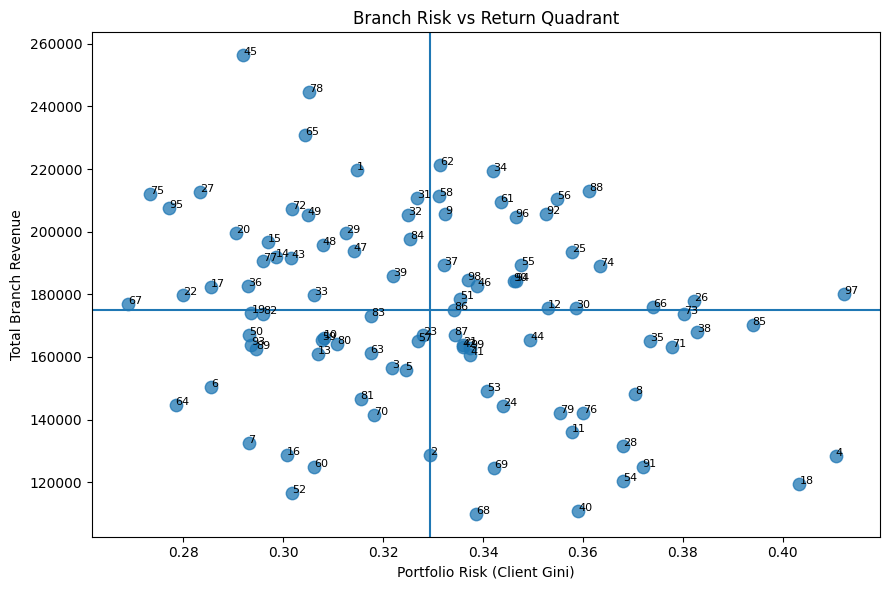

In [24]:
# =========================
# Risk vs Return Quadrant
# =========================

plot_df = branch_metrics.copy()

# Define metrics
risk_metric = "client_gini"
return_metric = "total_revenue"

# Median lines for quadrant split
risk_median = plot_df[risk_metric].median()
return_median = plot_df[return_metric].median()

plt.figure(figsize=(9,6))

plt.scatter(
    plot_df[risk_metric],
    plot_df[return_metric],
    s=80,
    alpha=0.75
)

# Label each branch
for _, row in plot_df.iterrows():
    plt.text(
        row[risk_metric],
        row[return_metric],
        str(int(row["branch_id"])),
        fontsize=8
    )

# Quadrant lines
plt.axvline(risk_median, linewidth=1.5)
plt.axhline(return_median, linewidth=1.5)


plt.xlabel("Portfolio Risk (Client Gini)")
plt.ylabel("Total Branch Revenue")
plt.title("Branch Risk vs Return Quadrant")

plt.tight_layout()
plt.show()


In [25]:
# =========================
# 19. Executive Branch Comparison Table (Updated for Total Revenue / Loan-Type Revenue)
# =========================

branch_metrics = branch_metrics.copy()
loan_mix = loan_mix.copy()

# -------------------------
# Ensure required fields exist
# -------------------------
required_defaults = {
    "interest_revenue": 0.0,
    "mortgage_interest_revenue": 0.0,
    "auto_interest_revenue": 0.0,
    "personal_interest_revenue": 0.0
}

for col, default_val in required_defaults.items():
    if col not in branch_metrics.columns:
        branch_metrics[col] = default_val
    branch_metrics[col] = branch_metrics[col].fillna(default_val)

if "estimated_revenue" not in branch_metrics.columns:
    branch_metrics["estimated_revenue"] = (
        branch_metrics["avg_transaction"] * branch_metrics["transactions"]
    )

if "total_revenue" not in branch_metrics.columns:
    branch_metrics["total_revenue"] = (
        branch_metrics["estimated_revenue"] +
        branch_metrics["interest_revenue"]
    )

if "RAR_total" not in branch_metrics.columns:
    branch_metrics["RAR_total"] = (
        branch_metrics["total_revenue"] /
        (1 - branch_metrics["RSI"] + 0.01)
    )

# -------------------------
# Create z-scores if missing
# -------------------------
zscore_map = [
    ("branch_hhi", "HHI_z"),
    ("avg_ccu", "CCU_z"),
    ("client_gini", "Gini_z"),
    ("RSI", "RSI_z"),
    ("total_revenue", "Total_Revenue_z"),
    ("RAR_total", "RAR_total_z"),
    ("transaction_cv", "Transaction_CV_z"),
    ("anomaly_rate", "Anomaly_z")
]

for raw_col, z_col in zscore_map:
    if raw_col in branch_metrics.columns and z_col not in branch_metrics.columns:
        std = branch_metrics[raw_col].std()
        if pd.notna(std) and std != 0:
            branch_metrics[z_col] = (
                (branch_metrics[raw_col] - branch_metrics[raw_col].mean()) / std
            )
        else:
            branch_metrics[z_col] = 0

# -------------------------
# Select branches by total risk-adjusted return
# -------------------------
top5 = (
    branch_metrics.sort_values("RAR_total", ascending=False)
    .head(5)["branch_id"]
    .tolist()
)

bottom5 = (
    branch_metrics.sort_values("RAR_total", ascending=True)
    .head(5)["branch_id"]
    .tolist()
)

selected_branches = top5 + bottom5

# -------------------------
# Loan mix pivot table
# -------------------------
loan_mix_table = loan_mix.pivot_table(
    index="loan_type",
    columns="branch_id",
    values="loan_share",
    aggfunc="mean"
)

avg_firm_loan_mix = loan_mix.groupby("loan_type")["loan_share"].mean()
loan_mix_table["Firm Avg"] = avg_firm_loan_mix

existing_branch_cols = [b for b in selected_branches if b in loan_mix_table.columns]
loan_mix_table = loan_mix_table[["Firm Avg"] + existing_branch_cols]

loan_mix_table = loan_mix_table * 100

loan_mix_table = loan_mix_table.rename(index={
    "Mortgage": "Mortgage %",
    "Auto": "Auto %",
    "Personal": "Personal %",
    "mortgage": "Mortgage %",
    "auto": "Auto %",
    "personal": "Personal %"
})

# -------------------------
# Core metrics setup
# -------------------------
metrics_indexed = branch_metrics.set_index("branch_id")

metric_map = {
    "Risk Score": "risk_score",
    "Revenue Stability Index": "RSI",
    "Estimated Transaction Revenue": "estimated_revenue",
    "Interest Revenue": "interest_revenue",
    "Mortgage Interest Revenue": "mortgage_interest_revenue",
    "Auto Interest Revenue": "auto_interest_revenue",
    "Personal Interest Revenue": "personal_interest_revenue",
    "Total Revenue": "total_revenue",
    "Total Risk-Adjusted Return": "RAR_total",
    "Risk Contribution %": "risk_contribution_percent",
    "Loan Exposure": "branch_loan_exposure",
    "Loan Approval Rate": "loan_approval_rate",
    "Loan Rejection Rate": "loan_rejection_rate",
    "Loan Closed Rate": "loan_closed_rate",
    "Client Concentration Gini": "client_gini",
    "Branch HHI": "branch_hhi",
    "Avg CCU": "avg_ccu",
    "Transaction CV": "transaction_cv",
    "Anomaly Rate": "anomaly_rate",
    "Avg Transaction": "avg_transaction",
    "Transactions": "transactions",
    "Avg Account Balance": "avg_account_balance",
    "Avg Interest Rate": "avg_interest_rate",
    "HHI Z-Score": "HHI_z",
    "CCU Z-Score": "CCU_z",
    "Gini Z-Score": "Gini_z",
    "RSI Z-Score": "RSI_z",
    "Total Revenue Z-Score": "Total_Revenue_z",
    "RAR_total Z-Score": "RAR_total_z",
    "Transaction CV Z-Score": "Transaction_CV_z",
    "Anomaly Z-Score": "Anomaly_z"
}

available_metric_map = {
    display_name: col_name
    for display_name, col_name in metric_map.items()
    if col_name in metrics_indexed.columns
}

metrics_rows = pd.DataFrame({
    branch: [
        metrics_indexed.loc[branch, col_name] if branch in metrics_indexed.index else np.nan
        for col_name in available_metric_map.values()
    ]
    for branch in selected_branches
}, index=list(available_metric_map.keys()))

metrics_rows["Firm Avg"] = [
    branch_metrics[col_name].mean() for col_name in available_metric_map.values()
]

ordered_cols = ["Firm Avg"] + top5 + bottom5
ordered_cols = [c for c in ordered_cols if c in metrics_rows.columns]
metrics_rows = metrics_rows[ordered_cols]

# -------------------------
# Helper for section rows
# -------------------------
def make_separator_row(label, columns):
    return pd.DataFrame(
        [[np.nan] * len(columns)],
        index=[label],
        columns=columns
    )

# -------------------------
# Define sections
# -------------------------
performance_rows = [
    r for r in [
        "Risk Score",
        "Revenue Stability Index",
        "Estimated Transaction Revenue",
        "Interest Revenue",
        "Mortgage Interest Revenue",
        "Auto Interest Revenue",
        "Personal Interest Revenue",
        "Total Revenue",
        "Total Risk-Adjusted Return",
        "Risk Contribution %",
        "Loan Exposure"
    ] if r in metrics_rows.index
]

credit_rows = [
    r for r in [
        "Loan Approval Rate",
        "Loan Rejection Rate",
        "Loan Closed Rate"
    ] if r in metrics_rows.index
]

concentration_rows = [
    r for r in [
        "Client Concentration Gini",
        "Branch HHI",
        "Avg CCU",
        "Transaction CV",
        "Anomaly Rate"
    ] if r in metrics_rows.index
]

activity_rows = [
    r for r in [
        "Avg Transaction",
        "Transactions",
        "Avg Account Balance",
        "Avg Interest Rate"
    ] if r in metrics_rows.index
]

zscore_rows = [
    r for r in [
        "HHI Z-Score",
        "CCU Z-Score",
        "Gini Z-Score",
        "RSI Z-Score",
        "Total Revenue Z-Score",
        "RAR_total Z-Score",
        "Transaction CV Z-Score",
        "Anomaly Z-Score"
    ] if r in metrics_rows.index
]

loan_mix_rows = [
    r for r in ["Mortgage %", "Auto %", "Personal %"]
    if r in loan_mix_table.index
]

# -------------------------
# Build final table
# -------------------------
table_parts = []

if performance_rows:
    table_parts.append(metrics_rows.loc[performance_rows])

if credit_rows:
    table_parts.append(make_separator_row("Credit / Loan Status Diagnostics", metrics_rows.columns))
    table_parts.append(metrics_rows.loc[credit_rows])

if concentration_rows:
    table_parts.append(make_separator_row("Concentration / Risk Diagnostics", metrics_rows.columns))
    table_parts.append(metrics_rows.loc[concentration_rows])

if activity_rows:
    table_parts.append(make_separator_row("Scale / Activity", metrics_rows.columns))
    table_parts.append(metrics_rows.loc[activity_rows])

if loan_mix_rows:
    table_parts.append(make_separator_row("Loan Portfolio Mix (%)", metrics_rows.columns))
    loan_mix_subset = loan_mix_table.loc[loan_mix_rows].copy()

    for col in metrics_rows.columns:
        if col not in loan_mix_subset.columns:
            loan_mix_subset[col] = np.nan

    loan_mix_subset = loan_mix_subset[metrics_rows.columns]
    table_parts.append(loan_mix_subset)

if zscore_rows:
    table_parts.append(make_separator_row("Standardized Relative Position", metrics_rows.columns))
    table_parts.append(metrics_rows.loc[zscore_rows])

final_table = pd.concat(table_parts)

# -------------------------
# Friendly column labels
# -------------------------
rename_cols = {"Firm Avg": "Firm Avg"}

for i, b in enumerate(top5):
    if b in final_table.columns:
        rename_cols[b] = f"Top RAR #{i+1} (Branch {b})"

for i, b in enumerate(bottom5):
    if b in final_table.columns:
        rename_cols[b] = f"Bottom RAR #{i+1} (Branch {b})"

final_table = final_table.rename(columns=rename_cols)

# -------------------------
# Safe rounding
# -------------------------
def safe_round(x, decimals=3):
    if isinstance(x, (int, float, np.integer, np.floating)) and pd.notna(x):
        return round(float(x), decimals)
    return x

final_table = final_table.apply(lambda col: col.map(lambda x: safe_round(x, 3)))
final_table.index.name = "Metric / Section"

# -------------------------
# Save raw CSV
# -------------------------
final_table.to_csv("executive_branch_comparison_table_updated.csv")

# -------------------------
# Build display-friendly version
# -------------------------
display_table = final_table.copy().astype(object)

percent_like_rows = {
    "Risk Contribution %",
    "Loan Approval Rate",
    "Loan Rejection Rate",
    "Loan Closed Rate",
    "Mortgage %",
    "Auto %",
    "Personal %",
    "Avg Interest Rate"
}

currency_like_rows = {
    "Estimated Transaction Revenue",
    "Interest Revenue",
    "Mortgage Interest Revenue",
    "Auto Interest Revenue",
    "Personal Interest Revenue",
    "Total Revenue",
    "Total Risk-Adjusted Return",
    "Loan Exposure",
    "Avg Transaction",
    "Avg Account Balance"
}

for idx in display_table.index:
    for col in display_table.columns:
        val = display_table.loc[idx, col]

        if isinstance(val, (int, float, np.integer, np.floating)) and pd.notna(val):
            if idx in percent_like_rows:
                display_table.loc[idx, col] = f"{val:.2%}" if val <= 1 else f"{val:.2f}%"
            elif idx in currency_like_rows:
                display_table.loc[idx, col] = f"{val:,.2f}"
            else:
                display_table.loc[idx, col] = f"{val:.3f}"
        elif pd.isna(val):
            display_table.loc[idx, col] = ""

display_table.to_csv("executive_branch_comparison_table_updated_display.csv")

print("\nExecutive Branch Comparison Table")
print(display_table)

print("\nTop 5 Branches by Total Risk-Adjusted Return:")
print(top5)

print("\nBottom 5 Branches by Total Risk-Adjusted Return:")
print(bottom5)



Executive Branch Comparison Table
                                    Firm Avg Top RAR #1 (Branch 17) Top RAR #2 (Branch 45) Top RAR #3 (Branch 27) Top RAR #4 (Branch 59)  \
Metric / Section                                                                                                                           
Revenue Stability Index                0.600                  0.946                  0.829                  0.851                  0.870   
Estimated Transaction Revenue     126,691.98             138,146.22             182,460.75             163,955.59             127,434.74   
Interest Revenue                   47,456.45              44,171.30              73,867.49              48,695.28              38,074.30   
Mortgage Interest Revenue          16,164.96              12,221.20              18,356.39              17,242.74              19,325.90   
Auto Interest Revenue              15,957.74              16,939.21              33,367.28              11,619.40            


Predictive Model: RAR_total (Non-Circular)
Train R^2: 0.319
Test R^2: 0.383
Test MAE: 187,348.78

Top Predictive Drivers of RAR_total
          feature   coefficient
      client_gini -1,882,721.22
       branch_hhi  1,000,072.83
          avg_ccu   -591,442.76
   mortgage_share   -501,678.40
       auto_share    474,909.66
avg_interest_rate   -126,575.59
   personal_share     26,768.74
     transactions     10,266.11
  avg_transaction        614.97

Prediction Sample
branch_id  actual_RAR_total  predicted_RAR_total  prediction_error
       45      1,412,782.62           934,072.62        478,710.00
        1        659,029.70           924,690.55       -265,660.86
       82        573,773.41           893,782.73       -320,009.32
       27      1,337,684.86           842,878.17        494,806.69
       19        723,229.71           778,271.87        -55,042.17


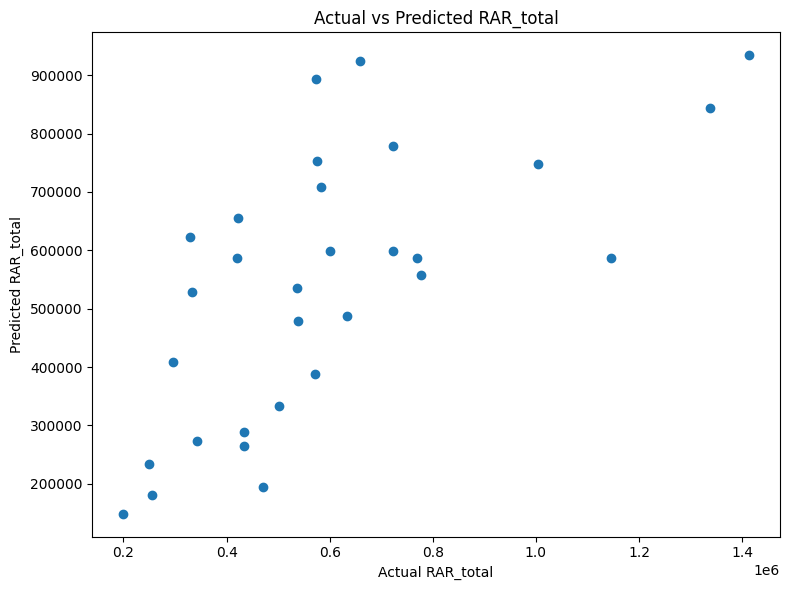

In [33]:
# =========================
# 19A. Predictive Model for RAR_total (Non-Circular)
# =========================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

model_df = branch_metrics.copy()

feature_cols = [
    "client_gini",
    "branch_hhi",
    "avg_ccu",
    "transactions",
    "avg_transaction",
    "avg_interest_rate",
    "mortgage_share",
    "auto_share",
    "personal_share"
]

feature_cols = [c for c in feature_cols if c in model_df.columns]
target_col = "RAR_total"

model_data = model_df[["branch_id", target_col] + feature_cols].dropna().copy()

if len(model_data) < 10:
    print("Warning: very small sample for prediction. Results are directional only.")

X = model_data[feature_cols]
y = model_data[target_col]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, model_data["branch_id"], test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print("\nPredictive Model: RAR_total (Non-Circular)")
print(f"Train R^2: {r2_score(y_train, y_pred_train):.3f}")
print(f"Test R^2: {r2_score(y_test, y_pred_test):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):,.2f}")

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

print("\nTop Predictive Drivers of RAR_total")
print(coef_table.to_string(index=False))

pred_results = pd.DataFrame({
    "branch_id": id_test,
    "actual_RAR_total": y_test,
    "predicted_RAR_total": y_pred_test,
    "prediction_error": y_test - y_pred_test
}).sort_values("predicted_RAR_total", ascending=False)

print("\nPrediction Sample")
print(pred_results.head().to_string(index=False))

coef_table.to_csv("rar_predictive_driver_coefficients.csv", index=False)
pred_results.to_csv("rar_prediction_results.csv", index=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual RAR_total")
plt.ylabel("Predicted RAR_total")
plt.title("Actual vs Predicted RAR_total")
plt.tight_layout()
plt.show()



Predictive Driver Ranking
             feature   coefficient
0        client_gini -1,882,721.22
1         branch_hhi  1,000,072.83
2            avg_ccu   -591,442.76
6     mortgage_share   -501,678.40
7         auto_share    474,909.66
5  avg_interest_rate   -126,575.59
8     personal_share     26,768.74
3       transactions     10,266.11
4    avg_transaction        614.97


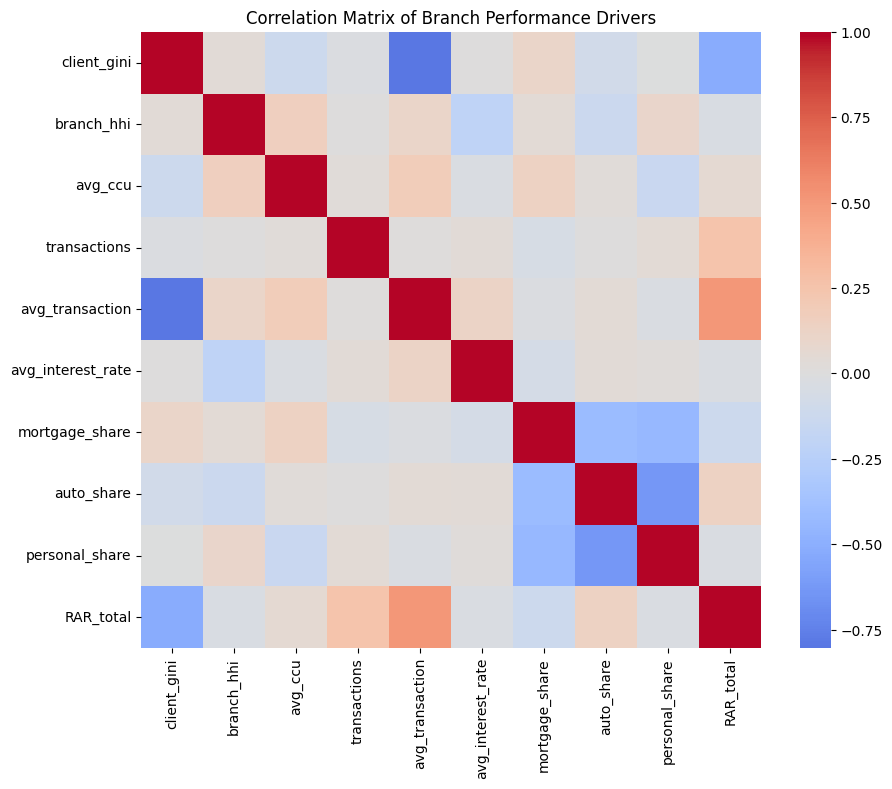

In [34]:
coef_table["abs_importance"] = coef_table["coefficient"].abs()

driver_ranking = coef_table.sort_values("abs_importance", ascending=False)

print("\nPredictive Driver Ranking")
print(driver_ranking[["feature","coefficient"]].head(10))
corr_vars = feature_cols + ["RAR_total"]

corr_matrix = branch_metrics[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Branch Performance Drivers")
plt.show()



In [35]:
# =========================
# 20. Save Final Portfolio Outputs
# =========================
branch_metrics.to_csv("branch_metrics_final_portfolio.csv", index=False)
Risk_Frontier.to_csv("branch_risk_frontier_final.csv", index=False)

print("\nSaved:")
print("- branch_metrics_final_portfolio.csv")
print("- branch_risk_frontier_final.csv")
print("- executive_branch_comparison_table.csv")
print("- executive_branch_comparison_table_display.csv")

# conn.close()
# print("\nDone.")



Saved:
- branch_metrics_final_portfolio.csv
- branch_risk_frontier_final.csv
- executive_branch_comparison_table.csv
- executive_branch_comparison_table_display.csv
